### Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Load data and Simulation

In [3]:
# Load the uploaded label file
df = pd.read_csv("train_rows.csv")

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SpMax_L      837 non-null    float64
 1   J_Dz(e)      837 non-null    float64
 2   nHM          837 non-null    int64  
 3   F01[N-N]     837 non-null    int64  
 4   F04[C-N]     837 non-null    int64  
 5   NssssC       837 non-null    int64  
 6   nCb-         837 non-null    int64  
 7   C%           837 non-null    float64
 8   nCp          837 non-null    int64  
 9   nO           837 non-null    int64  
 10  F03[C-N]     837 non-null    int64  
 11  SdssC        837 non-null    float64
 12  HyWi_B(m)    837 non-null    float64
 13  LOC          837 non-null    float64
 14  SM6_L        837 non-null    float64
 15  F03[C-O]     837 non-null    int64  
 16  Me           837 non-null    float64
 17  Mi           837 non-null    float64
 18  nN-N         837 non-null    int64  
 19  nArNO2       837 no

In [4]:
numeric_features = df.select_dtypes(include=["float64"]).columns
categorical_features = [
    col for col in df.select_dtypes(include=["int64"]).columns
    if col != "Class"
]

print("Numeric Features:", list(numeric_features))
print("Categorical Features (excluding Class):", list(categorical_features))

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_cat = encoder.fit_transform(df[categorical_features])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(categorical_features),
    index=df.index
)

df_combined = pd.concat([df[numeric_features], encoded_cat_df], axis=1)

scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_combined)

df_normalized = pd.DataFrame(
    normalized,
    columns=df_combined.columns,
    index=df_combined.index
)

print("\nFinal Preprocessed Data Shape:", df_normalized.shape)
df_normalized.head()

Numeric Features: ['SpMax_L', 'J_Dz(e)', 'C%', 'SdssC', 'HyWi_B(m)', 'LOC', 'SM6_L', 'Me', 'Mi', 'SpPosA_B(p)', 'SpMax_A', 'Psi_i_1d', 'SdO', 'TI2_L', 'SpMax_B(m)', 'Psi_i_A', 'SM6_B(m)']
Categorical Features (excluding Class): ['nHM', 'F01[N-N]', 'F04[C-N]', 'NssssC', 'nCb-', 'nCp', 'nO', 'F03[C-N]', 'F03[C-O]', 'nN-N', 'nArNO2', 'nCRX3', 'nCIR', 'B01[C-Br]', 'B03[C-Cl]', 'N-073', 'B04[C-Br]', 'nCrt', 'C-026', 'F02[C-N]', 'nHDon', 'nN', 'nArCOOR', 'nX']

Final Preprocessed Data Shape: (837, 238)


,SpMax_L,J_Dz(e),C%,SdssC,HyWi_B(m),LOC,SM6_L,Me,Mi,SpPosA_B(p),...,nX_3,nX_4,nX_5,nX_6,nX_7,nX_8,nX_10,nX_12,nX_23,nX_27
0,0.443187,0.265233,0.523333,0.520950,0.375752,0.567802,0.572377,0.008955,0.365854,0.448276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.501155,0.184201,0.513333,0.520950,0.220592,0.310176,0.539301,0.095522,0.371951,0.319629,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.446189,0.343988,0.445000,0.520950,0.417368,0.575596,0.585181,0.155224,0.396341,0.303714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.230947,0.267890,0.333333,0.520950,0.133750,0.204409,0.286900,0.450746,0.442073,0.213528,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.516397,0.364116,0.490000,0.493456,0.458263,0.613004,0.634736,0.140299,0.381098,0.363395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
categorical_features = [
    col for col in df.select_dtypes(include=["int64"]).columns
    if col != "Class"
]

if categorical_features:
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, drop='first')

    # Fit and transform categorical features
    encoded_array = encoder.fit_transform(df[categorical_features])

    # Get feature names
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)

    # Create DataFrame for encoded features
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    # Drop original categorical columns and add encoded ones
    df_encoded = df.drop(columns=categorical_features)
    df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
else:
    df_encoded = df.copy()
    encoded_feature_names = []

print(f"\nOriginal shape: {df.shape}")
print(f"After One Hot Encoding shape: {df_encoded.shape}")

X = df_encoded.drop(columns=["Class"])
y = df_encoded["Class"]

# Normalize all features

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
# Combine back with target
df_final = X_scaled.copy()
df_final["Class"] = y.values
df_final


Original shape: (837, 42)
After One Hot Encoding shape: (837, 215)


,SpMax_L,J_Dz(e),C%,SdssC,HyWi_B(m),LOC,SM6_L,Me,Mi,SpPosA_B(p),...,nX_4,nX_5,nX_6,nX_7,nX_8,nX_10,nX_12,nX_23,nX_27,Class
0,0.443187,0.265233,0.523333,0.520950,0.375752,0.567802,0.572377,0.008955,0.365854,0.448276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.501155,0.184201,0.513333,0.520950,0.220592,0.310176,0.539301,0.095522,0.371951,0.319629,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.446189,0.343988,0.445000,0.520950,0.417368,0.575596,0.585181,0.155224,0.396341,0.303714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.230947,0.267890,0.333333,0.520950,0.133750,0.204409,0.286900,0.450746,0.442073,0.213528,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.516397,0.364116,0.490000,0.493456,0.458263,0.613004,0.634736,0.140299,0.381098,0.363395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832,0.230947,0.131422,0.416667,0.520950,0.452730,0.204409,0.286900,0.083582,0.347561,0.689655,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
833,0.704619,0.383456,0.500000,0.440398,0.642290,0.789579,0.775697,0.101493,0.378049,0.368700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
834,0.664203,0.287272,0.500000,0.459268,0.400770,0.265642,0.696977,0.188060,0.402439,0.412467,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
835,0.681986,0.366097,0.666667,0.520950,0.434688,0.283456,0.687730,0.173134,0.326220,0.501326,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
X = df_final.drop('Class', axis=1)
y = df_final['Class']

print("=" * 60)
print("Data before Oversampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Oversampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# SMOTE Oversampling
print("Applying SMOTE Oversampling")

# Apply SMOTE
smote = SMOTE(random_state=209, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE - X shape: {X.shape}, y shape: {y.shape}")
print(f"After SMOTE  - X shape: {X_resampled.shape}, y shape: {y_resampled.shape}")

# Check new class distribution
print(f"\nClass distribution AFTER SMOTE:")
resampled_dist = Counter(y_resampled)
for cls, count in sorted(resampled_dist.items()):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier PCA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='Class')

# PCA with 95% threshold
print("PCA Analysis (95% Variance)")

# Initialize PCA with 95% threshold
pca_95 = PCA(n_components=0.95, random_state=209)

# Fit and transform data
X_pca = pca_95.fit_transform(X_resampled_df)

print(f"Number of real features: {X_resampled_df.shape[1]}")
print(f"Number of PCA components (95% variance): {X_pca.shape[1]}")
print(f"Cumulative variance ratio: {pca_95.explained_variance_ratio_.cumsum()[-1]:.4f}")

# Show explained variance ratio per component
print("\nExplained Variance Ratio per component:")
for i, ratio in enumerate(pca_95.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# Create final DataFrame with PCA results
df_pca_final = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
df_pca_final['Class'] = y_resampled.values

print("\n" + "=" * 60)
print("DATASET FINAL IS READY FOR FNN")
print("=" * 60)
print(f"Shape of final dataset: {df_pca_final.shape}")
print(f"PCA Features: {df_pca_final.columns[:-1].tolist()}")
print(f"Target: Class")
print(f"\nClass distribution in final dataset:")
print(df_pca_final['Class'].value_counts().sort_index())

print("\nDataset df_pca_final is ready for FNN training!")
print("Class weights have been calculated and can be used in the loss function.")
print(f"Number of optimal PCA components: {pca_95.n_components_}")
df_pca_final.to_csv('kimia_pca.csv', index=False)

Data before Oversampling
Shape X: (837, 214)
Shape y: (837,)

Class distribution before Oversampling:
Class
0    553
1    284
Name: count, dtype: int64
  Class 0: 553 samples (66.07%)
  Class 1: 284 samples (33.93%)
Class Weights
  Class 0: 0.7568
  Class 1: 1.4736
Applying SMOTE Oversampling
Before SMOTE - X shape: (837, 214), y shape: (837,)
After SMOTE  - X shape: (1106, 214), y shape: (1106,)

Class distribution AFTER SMOTE:
  Class 0: 553 samples (50.00%)
  Class 1: 553 samples (50.00%)
PCA Analysis (95% Variance)
Number of real features: 214
Number of PCA components (95% variance): 82
Cumulative variance ratio: 0.9504

Explained Variance Ratio per component:
  PC1: 0.0801 (8.01%)
  PC2: 0.0586 (5.86%)
  PC3: 0.0496 (4.96%)
  PC4: 0.0437 (4.37%)
  PC5: 0.0418 (4.18%)
  PC6: 0.0383 (3.83%)
  PC7: 0.0323 (3.23%)
  PC8: 0.0303 (3.03%)
  PC9: 0.0275 (2.75%)
  PC10: 0.0256 (2.56%)
  PC11: 0.0235 (2.35%)
  PC12: 0.0230 (2.30%)
  PC13: 0.0227 (2.27%)
  PC14: 0.0210 (2.10%)
  PC15: 0.0191

In [ ]:
# Preparation data (Using data from results of PCA)
# Assume that df_pca_final already exists from previous code
# Split features and target
X = df_pca_final.drop('Class', axis=1).values
y = df_pca_final['Class'].values

print(f"Shape X: {X.shape}")
print(f"Number of PCA features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Classes: 0=Inactive, 1=Active")

# Split Data (7-1-2)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=209, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)
# Trapezoidal Membership Function
def compute_membership_parameters(X_train):
    n_features = X_train.shape[1]
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    xmin = np.min(X_train, axis=0)
    xmax = np.max(X_train, axis=0)

    return mu, sigma, xmin, xmax

def trapmf(x, a, b, c, d):
    """
    Trapezoidal membership function
    trap(x; a,b,c,d) = max(0, min((x-a)/(b-a), 1, (d-x)/(d-c)))
    """
    if b - a == 0:  # Handle division by zero
        left_slope = 1.0
    else:
        left_slope = (x - a) / (b - a)

    if d - c == 0:  # Handle division by zero
        right_slope = 1.0
    else:
        right_slope = (d - x) / (d - c)

    return max(0, min(left_slope, 1, right_slope))

# FNN + Rule Attention
class FuzzyNeuralNetwork(nn.Module):
    def __init__(self, n_features, n_rules, n_classes, alpha=1.0,
                 mu=None, sigma=None, xmin=None, xmax=None):
        super(FuzzyNeuralNetwork, self).__init__()

        self.n_features = n_features
        self.n_rules = n_rules
        self.n_classes = n_classes
        self.alpha = alpha

        # Parameter membership (non-trainable)
        self.register_buffer('mu', torch.FloatTensor(mu))
        self.register_buffer('sigma', torch.FloatTensor(sigma))
        self.register_buffer('xmin', torch.FloatTensor(xmin))
        self.register_buffer('xmax', torch.FloatTensor(xmax))

        # Rule weights (trainable) - W_r,i,j ∈ R^{R × n × 3}
        self.rule_weights = nn.Parameter(
            torch.randn(n_rules, n_features, 3) * 0.05
        )

        # Rule biases (trainable) - b_r ∈ R^R
        self.rule_biases = nn.Parameter(torch.zeros(n_rules))

        # Rule norm
        self.rule_norm = nn.LayerNorm(n_rules)

        # Deep Decision Layers
        self.fc1 = nn.Linear(n_rules, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.4)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(32, n_classes)

        # Xavier Initialization
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.xavier_uniform_(self.fc4.weight)

    def compute_membership(self, x):
        batch_size = x.shape[0]
        membership = torch.zeros(batch_size, self.n_features, 3, device=x.device)
        for i in range(batch_size):
            for j in range(self.n_features):
                xi = x[i, j]
                # LOW
                a_low = self.xmin[j]
                b_low = self.xmin[j]
                c_low = self.mu[j] - self.alpha * self.sigma[j]
                d_low = self.mu[j]
                left_low = (xi - a_low) / (b_low - a_low + 1e-8)
                right_low = (d_low - xi) / (d_low - c_low + 1e-8)
                membership[i, j, 0] = torch.clamp(
                    torch.min(torch.min(left_low, torch.tensor(1.0, device=x.device)), right_low),
                    min=0
                )
                # MEDIUM
                a_med = self.mu[j] - self.alpha * self.sigma[j]
                b_med = self.mu[j]
                c_med = self.mu[j]
                d_med = self.mu[j] + self.alpha * self.sigma[j]
                left_med = (xi - a_med) / (b_med - a_med + 1e-8)
                right_med = (d_med - xi) / (d_med - c_med + 1e-8)
                membership[i, j, 1] = torch.clamp(
                    torch.min(torch.min(left_med, torch.tensor(1.0, device=x.device)), right_med),
                    min=0
                )
                # HIGH
                a_high = self.mu[j]
                b_high = self.mu[j] + self.alpha * self.sigma[j]
                c_high = self.xmax[j]
                d_high = self.xmax[j]
                left_high = (xi - a_high) / (b_high - a_high + 1e-8)
                right_high = (d_high - xi) / (d_high - c_high + 1e-8)
                membership[i, j, 2] = torch.clamp(
                    torch.min(torch.min(left_high, torch.tensor(1.0, device=x.device)), right_high),
                    min=0
                )
        return membership

    def forward(self, x):
        mu = self.compute_membership(x)
        z = torch.einsum('rfj,bfj->brf', self.rule_weights, mu)
        attention = torch.softmax(z, dim=2)
        f = torch.sum(attention * z, dim=2)
        f = f + self.rule_biases
        f = torch.softmax(f, dim=1)
        f = self.rule_norm(f)
        h = self.fc1(f)
        h = self.bn1(h)
        h = torch.relu(h)
        h = self.dropout1(h)
        h = self.fc2(h)
        h = self.bn2(h)
        h = torch.relu(h)
        h = self.dropout2(h)
        h = self.fc3(h)
        h = self.bn3(h)
        h = torch.relu(h)
        h = self.dropout3(h)
        output = self.fc4(h)
        return output, attention, f

# Compute class weights
def compute_class_weights(y, n_classes):
    n_total = len(y)
    class_counts = np.bincount(y)
    weights = n_total / (n_classes * class_counts)
    # Normalisasi sehingga rata-rata = 1
    weights = weights / np.mean(weights)
    return torch.FloatTensor(weights)

# Training Function
def train_fnn_model(X_train, y_train, X_val, y_val, X_test, y_test,
                    n_rules, alpha, learning_rate, batch_size, epochs,
                    class_weights, device='cuda' if torch.cuda.is_available() else 'cpu'):
    if y_train.ndim > 1:
        y_train = np.argmax(y_train, axis=1)
    if y_val.ndim > 1:
        y_val = np.argmax(y_val, axis=1)
    if y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.LongTensor(y_test).to(device)
    # Create data loaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialization model
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    # Calculate membership parameters from training data
    mu, sigma, xmin, xmax = compute_membership_parameters(X_train)

    model = FuzzyNeuralNetwork(
        n_features=n_features,
        n_rules=n_rules,
        n_classes=n_classes,
        alpha=alpha,
        mu=mu,
        sigma=sigma,
        xmin=xmin,
        xmax=xmax
    ).to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    # Scheduler: CosineAnnealingWarmRestarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-5
        )
    print("\n" + "=" * 60)
    print("Model Architecture")
    print("=" * 60)
    print(model)

# Calculate number of parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Training history
    history = {
        'train_loss': [], 'val_loss': [], 'test_loss': [],
        'train_acc': [], 'val_acc': [], 'test_acc': [],
        'train_f1': [], 'val_f1': [], 'test_f1': [],
        'train_auc': [], 'val_auc': [], 'test_auc': [],
        'lr': []
    }

    best_val_acc = 0
    best_model_state = None
    best_epoch = 0

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_targets = []

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Forward pass
            outputs, _, _ = model(batch_X)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()

            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_outputs, val_attention, val_firing = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            val_probs = F.softmax(val_outputs, dim=1).cpu().numpy()
            val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()

            test_outputs, test_attention, test_firing = model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t).item()
            test_probs = F.softmax(test_outputs, dim=1).cpu().numpy()
            test_preds = torch.argmax(test_outputs, dim=1).cpu().numpy()
            # Train probabilities
            train_outputs, _, _ = model(X_train_t)
            train_probs = F.softmax(train_outputs, dim=1).cpu().numpy()
            train_auc = roc_auc_score(y_train, train_probs[:,1])

        # Calculate metrics
        train_acc = accuracy_score(train_targets, train_preds)
        val_acc = accuracy_score(y_val, val_preds)
        test_acc = accuracy_score(y_test, test_preds)

        train_f1 = f1_score(train_targets, train_preds, average='weighted')
        val_f1 = f1_score(y_val, val_preds, average='weighted')
        test_f1 = f1_score(y_test, test_preds, average='weighted')

        # ROC-AUC OvR
        val_auc = roc_auc_score(y_val, val_probs[:,1])
        test_auc = roc_auc_score(y_test, test_probs[:,1])
        # Update scheduler
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        # Save history
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['test_acc'].append(test_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['test_f1'].append(test_f1)
        history['val_auc'].append(val_auc)
        history['test_auc'].append(test_auc)
        history['train_auc'].append(train_auc)
        history['lr'].append(current_lr)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            best_epoch = epoch + 1

        # Print progress every 25 epochs
        if (epoch + 1) % 1 == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} - "
                f"Train Loss: {train_loss/len(train_loader):.4f}, "
                f"Val Acc: {val_acc:.4f}, "
                f"Test Acc: {test_acc:.4f}, "
                f"Train AUC: {train_auc:.4f}, "
                f"Val AUC: {val_auc:.4f}, "
                f"Test AUC: {test_auc:.4f}"
            )

    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\nBest model found at epoch {best_epoch} with Val Acc: {best_val_acc:.4f}")

    # Final evaluation with best model
    model.eval()
    with torch.no_grad():
        final_train_outputs, final_train_attention, final_train_firing = model(X_train_t)
        final_val_outputs, final_val_attention, final_val_firing = model(X_val_t)
        final_test_outputs, final_test_attention, final_test_firing = model(X_test_t)

        final_train_preds = torch.argmax(final_train_outputs, dim=1).cpu().numpy()
        final_val_preds = torch.argmax(final_val_outputs, dim=1).cpu().numpy()
        final_test_preds = torch.argmax(final_test_outputs, dim=1).cpu().numpy()

        final_train_acc = accuracy_score(y_train, final_train_preds)
        final_val_acc = accuracy_score(y_val, final_val_preds)
        final_test_acc = accuracy_score(y_test, final_test_preds)

        final_train_f1 = f1_score(y_train, final_train_preds, average='weighted')
        final_val_f1 = f1_score(y_val, final_val_preds, average='weighted')
        final_test_f1 = f1_score(y_test, final_test_preds, average='weighted')

        final_val_probs = final_val_outputs.softmax(dim=1).cpu().numpy()
        final_test_probs = final_test_outputs.softmax(dim=1).cpu().numpy()
        final_train_probs = final_train_outputs.softmax(dim=1).cpu().numpy()

        final_val_auc = roc_auc_score(y_val, final_val_probs[:,1])
        final_test_auc = roc_auc_score(y_test, final_test_probs[:,1])
        final_train_auc = roc_auc_score(y_train, final_train_probs[:,1])


    print(f"\n{'='*60}")
    print(f"FINAL RESULTS:")
    print(f"{'='*60}")
    print(f"Train Accuracy: {final_train_acc:.4f} | Train F1: {final_train_f1:.4f}")
    print(f"Train AUC: {final_train_auc:.4f}")
    print(f"Val Accuracy:   {final_val_acc:.4f} | Val F1:   {final_val_f1:.4f}")
    print(f"Test Accuracy:  {final_test_acc:.4f} | Test F1:  {final_test_f1:.4f}")
    print(f"Val AUC:       {final_val_auc:.4f} | Test AUC: {final_test_auc:.4f}")
    print(f"{'='*60}")

    return model, history, {
        'train_preds': final_train_preds,
        'val_preds': final_val_preds,
        'test_preds': final_test_preds,
        'train_attention': final_train_attention.cpu().numpy(),
        'val_attention': final_val_attention.cpu().numpy(),
        'test_attention': final_test_attention.cpu().numpy(),
        'train_firing': final_train_firing.cpu().numpy(),
        'val_firing': final_val_firing.cpu().numpy(),
        'test_firing': final_test_firing.cpu().numpy()
    }

# Plotting Functions
def plot_training_history(history, alpha_value):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    epochs = range(1, len(history['train_loss']) + 1)
    # Loss plot
    axes[0,0].plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
    axes[0,0].plot(epochs, history['val_loss'],  label='Val Loss', linewidth=2)
    axes[0,0].plot(epochs, history['test_loss'],  label='Test Loss', linewidth=2)
    axes[0,0].set_xlabel('Epochs', fontsize=12)
    axes[0,0].set_ylabel('Loss', fontsize=12)
    axes[0,0].set_title(f'Loss History', fontsize=14)
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[0,1].plot(epochs, history['train_acc'],  label='Train Acc', linewidth=2)
    axes[0,1].plot(epochs, history['val_acc'],  label='Val Acc', linewidth=2)
    axes[0,1].plot(epochs, history['test_acc'],  label='Test Acc', linewidth=2)
    axes[0,1].set_xlabel('Epochs', fontsize=12)
    axes[0,1].set_ylabel('Accuracy', fontsize=12)
    axes[0,1].set_title(f'Accuracy History', fontsize=14)
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # F1-score plot
    axes[1,0].plot(epochs, history['train_f1'],  label='Train F1', linewidth=2)
    axes[1,0].plot(epochs, history['val_f1'],  label='Val F1', linewidth=2)
    axes[1,0].plot(epochs, history['test_f1'],  label='Test F1', linewidth=2)
    axes[1,0].set_xlabel('Epochs', fontsize=12)
    axes[1,0].set_ylabel('F1-Score', fontsize=12)
    axes[1,0].set_title(f'F1-Score History', fontsize=14)
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # AUC plot
    axes[1,1].plot(epochs, history['train_auc'],  label='Train AUC', linewidth=2)
    axes[1,1].plot(epochs, history['val_auc'],  label='Val AUC', linewidth=2)
    axes[1,1].plot(epochs, history['test_auc'],  label='Test AUC', linewidth=2)
    axes[1,1].set_xlabel('Epochs', fontsize=12)
    axes[1,1].set_ylabel('AUC', fontsize=12)
    axes[1,1].set_title(f'AUC History', fontsize=14)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle(f'FNN Training History',
                fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(y_true, y_pred, class_names=None):
    if class_names is None:
        class_names = ['Inactive', 'Active']

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted', fontsize=10)
    plt.ylabel('Actual', fontsize=10)
    plt.title(f'Confusion Matrix (FNN - Kimia)',
              fontsize=10)
    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Execution Simulation
# Specific parameter, for sensitivity analysis chose one of these arrays below
#learning_rate_list = [0.005, 0.01, 0.05, 0.1]
LEARNING_RATE = 0.005
#alpha_list = [1, 1.6, 0.5, 0.1]
ALPHA = 1
# BATCH_SIZE = 32
batch_size_list = [32, 64, 128, 256]
EPOCHS = 30  
test_acc_results = []
test_auc_results = []
# Hitung jumlah aturan R = min{max{15, n×2}, 16}
n_features = X.shape[1]
n_rules = 10
print(f"\nJumlah fitur PCA: {n_features}")
print(f"Jumlah aturan (R): {n_rules}")

# Class weights
class_weights = compute_class_weights(y, n_classes=3)
print(f"\nClass weights: {class_weights.numpy()}")

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Training model
for batch_size in batch_size_list:
    model, history, predictions = train_fnn_model(
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        n_rules=n_rules,
        alpha=ALPHA,
        learning_rate=LEARNING_RATE,
        batch_size=batch_size,
        epochs=EPOCHS,
        class_weights=class_weights,
        device=device
    )

# Results

    print("Results")

# Plot training history
    plot_training_history(history, alpha_value=ALPHA)

# Plot confusion matrix for Test Set
    plot_confusion_matrices(
        y_test, predictions['test_preds'],
        class_names=['Inactive', 'Active']
    )
    print("\n" + "="*60)
    print("Results")
    print("="*60)
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Alpha (α): {ALPHA}")
    print(f"Batch Size: {batch_size}")
    print(f"Epochs: {EPOCHS}")
    print(f"Number of rules (R): {n_rules}")
    print("-" * 40)
    print(f"Train Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Validation Accuracy: {history['val_acc'][-1]:.4f}")
    print(f"Test Accuracy: {history['test_acc'][-1]:.4f}")
    print("-" * 40)
    print(f"Train F1-Score: {history['train_f1'][-1]:.4f}")
    print(f"Validation F1-Score: {history['val_f1'][-1]:.4f}")
    print(f"Test F1-Score: {history['test_f1'][-1]:.4f}")
    print("-" * 40)
    print(f"Best Validation Accuracy: {max(history['val_acc']):.4f}")
    print(f"Best Test Accuracy: {max(history['test_acc']):.4f}")
    print("="*60)

Shape X: (1106, 82)
Number of PCA features: 82
Number of classes: 2
Class distribution: [553 553]
Classes: 0=Inactive, 1=Active

Jumlah fitur PCA: 82
Jumlah aturan (R): 10

Class weights: [1. 1.]
Using device: cpu

Model Architecture
FuzzyNeuralNetwork(
  (rule_norm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=10, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 14,748
Trainable

KeyboardInterrupt: 

### Plot Sensitivity Analysis

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

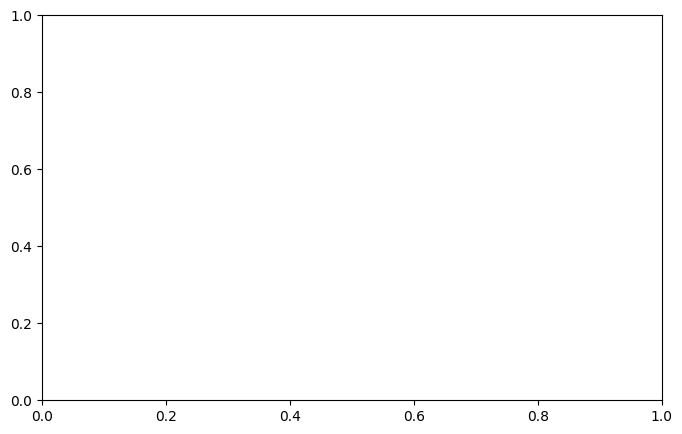

In [10]:
epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(8,5))
plt.plot(epochs, test_acc_results[0:int(4*EPOCHS*(1/4))], linewidth=1.5, marker='o', label="Size = 32")
plt.plot(epochs, test_acc_results[int(4*EPOCHS*(1/4)):int(4*EPOCHS*(2/4))], linewidth=1.5, marker='o', label="Size = 64")
plt.plot(epochs, test_acc_results[int(4*EPOCHS*(2/4)):int(4*EPOCHS*(3/4))], linewidth=1.5, marker='o', label="Size = 128")
plt.plot(epochs, test_acc_results[int(4*EPOCHS*(3/4)):], linewidth=1.5, marker='o', label="Size = 256")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Comparison Batch Size to Accuracy")
plt.grid(True)
plt.legend()
plt.show()

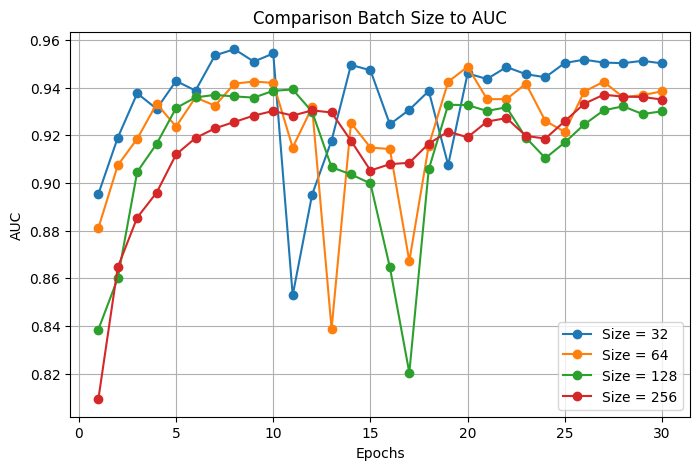

In [17]:
plt.figure(figsize=(8,5))
plt.plot(epochs, test_auc_results[0:int(4*EPOCHS*(1/4))], linewidth=1.5, marker='o', label="Size = 32")
plt.plot(epochs, test_auc_results[int(4*EPOCHS*(1/4)):int(4*EPOCHS*(2/4))], linewidth=1.5, marker='o', label="Size = 64")
plt.plot(epochs, test_auc_results[int(4*EPOCHS*(2/4)):int(4*EPOCHS*(3/4))], linewidth=1.5, marker='o', label="Size = 128")
plt.plot(epochs, test_auc_results[int(4*EPOCHS*(3/4)):], linewidth=1.5, marker='o', label="Size = 256")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.title("Comparison Batch Size to AUC")
plt.grid(True)
plt.legend()
plt.show()